# CIFAR-10 Object Recognition with a Convolutional Neural Network

This notebook is the complete, self-contained implementation of a from-scratch CNN that classifies CIFAR-10 images (32x32 RGB) into 10 object categories. Everything that previously lived in the `cifar10_cnn/` Python package is consolidated here, so the whole pipeline can be run end to end inside Anaconda without importing any local module.

**Pipeline:** `load -> split -> tf.data -> augment -> build model -> train -> evaluate -> predict`

## Requirements

Install the dependencies once into your Anaconda environment:

```
conda install -c conda-forge tensorflow numpy pandas scikit-learn matplotlib seaborn
```

or, if you prefer pip:

```
pip install tensorflow numpy pandas scikit-learn matplotlib seaborn
```

## How to run

1. Run the cells from top to bottom. Sections 1-5 define the configuration, the data pipeline and the model, and are cheap to run.
2. Section 7 performs the actual training. Setting `CONFIG.quick_run = True` finishes in a couple of minutes on CPU and is useful to verify the plumbing before a long run.
3. After training, Section 10 evaluates the best checkpoint and Section 11 classifies single images.

All outputs (model checkpoint, figures and JSON metrics) are written under `artifacts/`.

## 1. Environment setup

Import every library used by the notebook and print the versions TensorFlow will run with. On TensorFlow 2.15 you will see oneDNN / deprecation warnings on import - these are benign and expected.

In [1]:
import json
import os
import random
import sys
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("pandas     :", pd.__version__)
print("Python     :", sys.version.split()[0])


TensorFlow : 2.15.0
NumPy      : 1.24.3
pandas     : 1.5.3
Python     : 3.11.5


## 2. Configuration

All tunable values live in one place. `CLASS_NAMES`, `IMAGE_SIZE` and the filesystem layout are fixed by CIFAR-10 and by the project; every hyperparameter lives on the `TrainConfig` dataclass so that a run can be described and serialised by a single object.

In [2]:
NUM_CLASSES = 10
IMAGE_SIZE = 32
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)
PIXEL_SCALE = 255.0

CLASS_NAMES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

# Filesystem layout: every output the pipeline writes lands under artifacts/.
PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
LOGS_DIR = ARTIFACTS_DIR / "logs"

DEFAULT_MODEL_PATH = MODELS_DIR / "cifar10_cnn.keras"
HISTORY_PATH = REPORTS_DIR / "history.json"
METRICS_PATH = REPORTS_DIR / "test_metrics.json"

print("Project root :", PROJECT_ROOT)
print("Image size   :", IMAGE_SIZE)
print("Input shape  :", INPUT_SHAPE)
print("Classes      :", len(CLASS_NAMES), "->", ", ".join(CLASS_NAMES))

Project root : C:\Users\car info\Desktop\proj git\cnn object recognition
Image size   : 32
Input shape  : (32, 32, 3)
Classes      : 10 -> airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


In [3]:
@dataclass
class TrainConfig:
    """Hyperparameters for a training run.

    Defaults are tuned for CPU-only training of a from-scratch CNN: a moderate
    batch size, a deeper-but-narrow network, and aggressive regularisation
    (augmentation + dropout + batch norm) so the model can be trained for many
    epochs without overfitting.
    """

    # Reproducibility
    seed: int = 42

    # Optimisation
    batch_size: int = 64
    epochs: int = 60
    learning_rate: float = 1e-3

    # Data
    validation_split: float = 0.1
    shuffle_buffer: int = 10_000

    # Architecture
    conv_filters: tuple = (32, 64, 128)
    conv_blocks_per_stage: int = 2
    dense_units: int = 256
    dropout_conv: tuple = (0.20, 0.30, 0.40)
    dropout_dense: float = 0.50
    weight_decay: float = 1e-4

    # Augmentation
    use_augmentation: bool = True
    flip_horizontal: bool = True
    translation: float = 0.125
    rotation: float = 0.10
    zoom: float = 0.10

    # Callbacks
    early_stopping_patience: int = 15
    reduce_lr_patience: int = 5
    reduce_lr_factor: float = 0.5
    min_learning_rate: float = 1e-6

    # Housekeeping
    quick_run: bool = False
    run_name: str = "cifar10_cnn"
    tags: dict = field(default_factory=dict)

    @property
    def model_path(self) -> Path:
        return MODELS_DIR / f"{self.run_name}.keras"

    @property
    def history_path(self) -> Path:
        return REPORTS_DIR / f"{self.run_name}_history.json"

    @property
    def metrics_path(self) -> Path:
        return REPORTS_DIR / f"{self.run_name}_metrics.json"

    @property
    def log_path(self) -> Path:
        return LOGS_DIR / f"{self.run_name}.csv"

    def effective_epochs(self) -> int:
        """Epochs actually used, with a short schedule for smoke tests."""
        return 2 if self.quick_run else self.epochs

    def effective_train_limit(self):
        """Cap the number of training examples for smoke tests."""
        return 2_000 if self.quick_run else None

    def to_dict(self) -> dict:
        payload = asdict(self)
        payload["conv_filters"] = list(self.conv_filters)
        payload["dropout_conv"] = list(self.dropout_conv)
        payload["effective_epochs"] = self.effective_epochs()
        return payload

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(self.to_dict(), indent=2), encoding="utf-8")


def ensure_directories() -> None:
    """Create every output directory the pipeline writes into."""
    for directory in (ARTIFACTS_DIR, MODELS_DIR, REPORTS_DIR, LOGS_DIR):
        directory.mkdir(parents=True, exist_ok=True)


CONFIG = TrainConfig()
ensure_directories()
CONFIG

TrainConfig(seed=42, batch_size=64, epochs=60, learning_rate=0.001, validation_split=0.1, shuffle_buffer=10000, conv_filters=(32, 64, 128), conv_blocks_per_stage=2, dense_units=256, dropout_conv=(0.2, 0.3, 0.4), dropout_dense=0.5, weight_decay=0.0001, use_augmentation=True, flip_horizontal=True, translation=0.125, rotation=0.1, zoom=0.1, early_stopping_patience=15, reduce_lr_patience=5, reduce_lr_factor=0.5, min_learning_rate=1e-06, quick_run=False, run_name='cifar10_cnn', tags={})

## 3. Reproducibility and runtime setup

`set_global_seed` seeds Python, NumPy and TensorFlow. `prepare_runtime` forces the console to UTF-8 (so Keras' box-drawing characters never raise `UnicodeEncodeError` on Windows) and lets TensorFlow allocate GPU memory incrementally when a GPU is present.

In [4]:
def set_global_seed(seed: int) -> None:
    """Seed every random-number source used by the project.

    Full bit-for-bit determinism on GPU also requires disabling cuDNN
    autotuning, which costs performance. Seeding the standard generators is
    enough to make runs comparable across attempts.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def use_utf8_console() -> None:
    """Force stdout/stderr to UTF-8 where the stream supports it."""
    for stream in (sys.stdout, sys.stderr):
        reconfigure = getattr(stream, "reconfigure", None)
        if reconfigure is None:
            continue
        try:
            reconfigure(encoding="utf-8")
        except (ValueError, OSError):
            # Stream is not reconfigurable - harmless.
            pass


def enable_memory_growth() -> None:
    """Let TensorFlow allocate GPU memory incrementally when a GPU exists."""
    for device in tf.config.list_physical_devices("GPU"):
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError:
            # Already initialised - nothing to do.
            pass


def describe_devices() -> str:
    """Human-readable summary of the hardware TensorFlow will use."""
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        return "GPU: " + ", ".join(gpu.name for gpu in gpus)
    return "CPU only (no GPU detected)"


def prepare_runtime() -> str:
    """Apply console/device setup and return a device description."""
    use_utf8_console()
    enable_memory_growth()
    return describe_devices()


set_global_seed(CONFIG.seed)
print("Running on:", prepare_runtime())

Running on: CPU only (no GPU detected)


## 4. Data pipeline

Raw images are kept as `uint8` and cached in that form, which holds the entire training set in roughly 150 MB of RAM. Normalisation and augmentation run after batching so the preprocessing layers execute vectorised.

In [5]:
def normalize_images(images: tf.Tensor) -> tf.Tensor:
    """Scale uint8 pixel values in [0, 255] to float32 in [0, 1]."""
    return tf.cast(images, tf.float32) / PIXEL_SCALE


def split_train_validation(
    images: np.ndarray,
    labels: np.ndarray,
    validation_split: float,
    seed: int,
):
    """Randomly hold out a validation fraction from the training arrays."""
    if not 0.0 <= validation_split < 1.0:
        raise ValueError(f"validation_split must be in [0, 1), got {validation_split}")

    num_samples = len(images)
    if num_samples == 0:
        raise ValueError("Cannot split an empty dataset")

    rng = np.random.default_rng(seed)
    shuffled_indices = rng.permutation(num_samples)

    num_val = int(round(num_samples * validation_split))
    if validation_split > 0:
        # Always leave at least one training example.
        num_val = min(max(num_val, 1), num_samples - 1)

    val_indices = shuffled_indices[:num_val]
    train_indices = shuffled_indices[num_val:]

    return (
        images[train_indices],
        labels[train_indices],
        images[val_indices],
        labels[val_indices],
    )


def load_cifar10():
    """Download (if needed) and return CIFAR-10 as uint8 arrays.

    Label arrays are squeezed from (N, 1) to (N,) so they can be used directly
    with sparse categorical cross-entropy.
    """
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    return (
        x_train.astype(np.uint8),
        y_train.reshape(-1).astype(np.int32),
        x_test.astype(np.uint8),
        y_test.reshape(-1).astype(np.int32),
    )


x_train_uint8, y_train_labels, x_test_uint8, y_test_labels = load_cifar10()
print("x_train:", x_train_uint8.shape, x_train_uint8.dtype)
print("y_train:", y_train_labels.shape, y_train_labels.dtype)
print("x_test :", x_test_uint8.shape, x_test_uint8.dtype)
print("y_test :", y_test_labels.shape, y_test_labels.dtype)
print("pixel range:", int(x_train_uint8.min()), "->", int(x_train_uint8.max()))

x_train: (50000, 32, 32, 3) uint8
y_train: (50000,) int32
x_test : (10000, 32, 32, 3) uint8
y_test : (10000,) int32
pixel range: 0 -> 255


### 4.1 Visual sanity check

Ten test images with their ground-truth labels, to confirm the dataset loaded correctly.

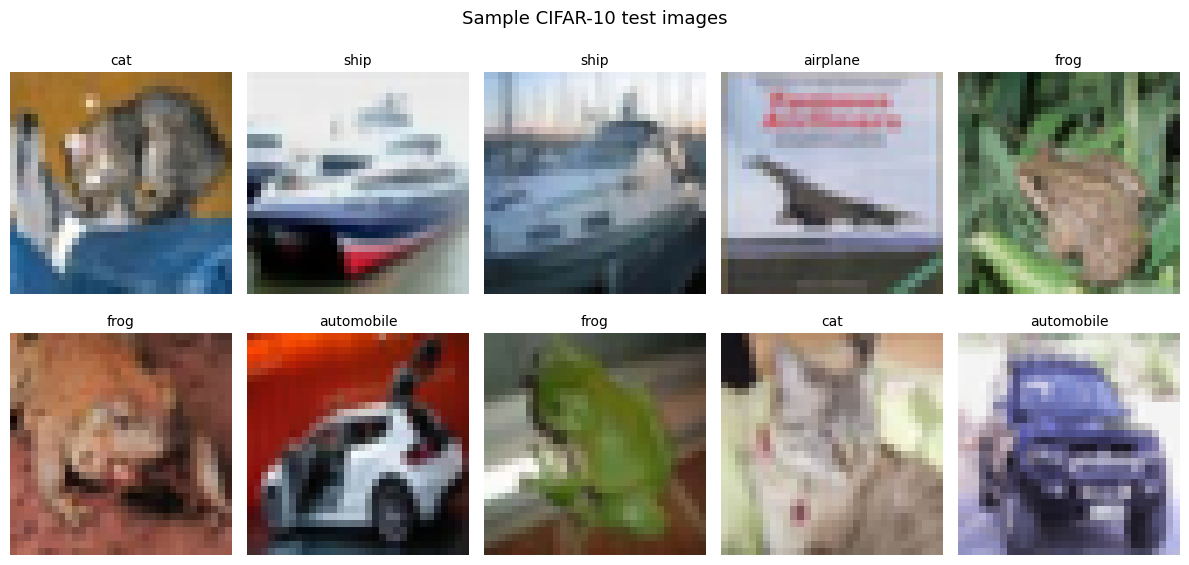

In [6]:
plt.figure(figsize=(12, 6))
for index in range(10):
    plt.subplot(2, 5, index + 1)
    plt.imshow(x_test_uint8[index])
    plt.title(CLASS_NAMES[int(y_test_labels[index])], fontsize=10)
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 test images", fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Augmentation

The augmentation stack is a `tf.keras.Sequential` of preprocessing layers. It is applied inside the training map function only, so it is automatically inactive for validation, test and inference.

In [7]:
def build_augmentation(config: TrainConfig) -> tf.keras.Sequential:
    """Return a Keras layer stack that stochastically augments a batch.

    Each transform is either enabled or omitted entirely, so an empty stack is
    returned when augmentation is disabled.
    """
    layers = []

    if not config.use_augmentation:
        return tf.keras.Sequential(layers, name="augmentation")

    if config.flip_horizontal:
        layers.append(tf.keras.layers.RandomFlip(mode="horizontal", seed=config.seed))

    if config.translation > 0:
        layers.append(
            tf.keras.layers.RandomTranslation(
                height_factor=config.translation,
                width_factor=config.translation,
                fill_mode="reflect",
                seed=config.seed,
            )
        )

    if config.rotation > 0:
        layers.append(
            tf.keras.layers.RandomRotation(
                factor=config.rotation,
                fill_mode="reflect",
                seed=config.seed,
            )
        )

    if config.zoom > 0:
        layers.append(
            tf.keras.layers.RandomZoom(
                height_factor=config.zoom,
                width_factor=config.zoom,
                fill_mode="reflect",
                seed=config.seed,
            )
        )

    return tf.keras.Sequential(layers, name="augmentation")


def is_augmentation_active(config: TrainConfig) -> bool:
    """Whether any augmentation transform would actually be applied."""
    if not config.use_augmentation:
        return False
    return bool(
        config.flip_horizontal
        or config.translation > 0
        or config.rotation > 0
        or config.zoom > 0
    )


print("Augmentation active:", is_augmentation_active(CONFIG))
print("Transforms:", [layer.name for layer in build_augmentation(CONFIG).layers])

Augmentation active: True

Transforms: ['random_flip', 'random_translation', 'random_rotation', 'random_zoom']


### 4.3 tf.data pipelines

`build_train_dataset` shuffles, batches, normalises and augments; `build_eval_dataset` is the deterministic version used for validation and testing. Both are backed by `cache()` so the data is converted to tensors once.

In [8]:
def _prepare_batch(
    images: tf.Tensor,
    labels: tf.Tensor,
    augment,
):
    """Normalise a batch and optionally apply augmentation to the images."""
    images = normalize_images(images)
    if augment is not None:
        images = augment(images, training=True)
    return images, labels


def build_train_dataset(
    images: np.ndarray,
    labels: np.ndarray,
    config: TrainConfig,
) -> tf.data.Dataset:
    """Shuffled, normalised, optionally augmented dataset for training."""
    augmentation = (
        build_augmentation(config) if is_augmentation_active(config) else None
    )

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.cache()
    dataset = dataset.shuffle(
        buffer_size=min(config.shuffle_buffer, len(images)),
        seed=config.seed,
        reshuffle_each_iteration=True,
    )
    dataset = dataset.batch(config.batch_size, drop_remainder=False)
    dataset = dataset.map(
        lambda x, y: _prepare_batch(x, y, augmentation),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


def build_eval_dataset(
    images: np.ndarray,
    labels: np.ndarray,
    config: TrainConfig,
) -> tf.data.Dataset:
    """Deterministic, normalised dataset used for validation and testing."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.cache()
    dataset = dataset.batch(config.batch_size, drop_remainder=False)
    dataset = dataset.map(
        lambda x, y: _prepare_batch(x, y, None),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


class DatasetBundle(NamedTuple):
    """The three splits plus their sizes."""

    train: tf.data.Dataset
    val: tf.data.Dataset
    test: tf.data.Dataset
    num_train: int
    num_val: int
    num_test: int


def load_test_arrays(config: TrainConfig):
    """Return only the test split, honouring the quick-run subset limit."""
    _, _, x_test, y_test = load_cifar10()

    limit = config.effective_train_limit()
    if limit is not None:
        x_test, y_test = x_test[:limit], y_test[:limit]

    return x_test, y_test


def build_datasets(config: TrainConfig) -> DatasetBundle:
    """Load CIFAR-10 and build the train / validation / test pipelines."""
    x_train, y_train, x_test, y_test = load_cifar10()

    x_train, y_train, x_val, y_val = split_train_validation(
        x_train, y_train, config.validation_split, config.seed
    )

    limit = config.effective_train_limit()
    if limit is not None:
        x_train, y_train = x_train[:limit], y_train[:limit]
        x_val, y_val = x_val[: max(limit // 10, 1)], y_val[: max(limit // 10, 1)]
        x_test, y_test = x_test[:limit], y_test[:limit]

    return DatasetBundle(
        train=build_train_dataset(x_train, y_train, config),
        val=build_eval_dataset(x_val, y_val, config),
        test=build_eval_dataset(x_test, y_test, config),
        num_train=len(x_train),
        num_val=len(x_val),
        num_test=len(x_test),
    )


bundle = build_datasets(CONFIG)
print(f"Train / Val / Test: {bundle.num_train} / {bundle.num_val} / {bundle.num_test}")

for images, labels in bundle.train.take(1):
    print("train batch:", images.shape, images.dtype, float(tf.reduce_min(images)), "->", float(tf.reduce_max(images)))

Train / Val / Test: 45000 / 5000 / 10000
train batch: (64, 32, 32, 3) <dtype: 'float32'> 0.0 -> 1.0


## 5. Model architecture

The network is three convolutional stages deep. Each stage stacks `conv -> batch-norm -> relu` blocks followed by max-pooling and dropout. Batch normalisation makes the deeper stack trainable at a higher learning rate, and the dropout schedule increases with depth where the feature maps are most likely to overfit.

In [9]:
def _stage_dropouts(config: TrainConfig) -> tuple:
    """Dropout rate per convolutional stage, padding with the last value."""
    rates = tuple(config.dropout_conv)
    if not rates:
        return tuple(0.0 for _ in config.conv_filters)
    if len(rates) >= len(config.conv_filters):
        return rates[: len(config.conv_filters)]
    return rates + (rates[-1],) * (len(config.conv_filters) - len(rates))


def _kernel_regularizer(config: TrainConfig):
    """L2 weight decay, or None when disabled."""
    if config.weight_decay <= 0:
        return None
    return tf.keras.regularizers.l2(config.weight_decay)


def _add_conv_stage(
    model: tf.keras.Sequential,
    stage_index: int,
    filters: int,
    config: TrainConfig,
    dropout_rate: float,
) -> None:
    """Append one conv x N -> pool -> dropout stage to the model."""
    regularizer = _kernel_regularizer(config)

    for block_index in range(config.conv_blocks_per_stage):
        suffix = f"{stage_index + 1}_{block_index + 1}"
        model.add(
            tf.keras.layers.Conv2D(
                filters=filters,
                kernel_size=3,
                padding="same",
                use_bias=False,
                kernel_regularizer=regularizer,
                name=f"conv_{suffix}",
            )
        )
        model.add(tf.keras.layers.BatchNormalization(name=f"bn_{suffix}"))
        model.add(tf.keras.layers.Activation("relu", name=f"relu_{suffix}"))

    model.add(tf.keras.layers.MaxPool2D(pool_size=2, name=f"pool_{stage_index + 1}"))

    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(dropout_rate, name=f"dropout_{stage_index + 1}"))


def compile_model(model: tf.keras.Model, config: TrainConfig) -> tf.keras.Model:
    """Attach optimizer, loss, and metrics to an existing model."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"],
    )
    return model


def build_model(config: TrainConfig) -> tf.keras.Model:
    """Construct and compile the CNN described by config."""
    if not config.conv_filters:
        raise ValueError("config.conv_filters must contain at least one stage")

    dropouts = _stage_dropouts(config)
    regularizer = _kernel_regularizer(config)

    model = tf.keras.Sequential(name=config.run_name)
    model.add(tf.keras.layers.Input(shape=INPUT_SHAPE, name="input"))

    for stage_index, (filters, dropout_rate) in enumerate(
        zip(config.conv_filters, dropouts)
    ):
        _add_conv_stage(model, stage_index, filters, config, dropout_rate)

    model.add(tf.keras.layers.Flatten(name="flatten"))
    model.add(
        tf.keras.layers.Dense(
            config.dense_units,
            use_bias=False,
            kernel_regularizer=regularizer,
            name="dense_head",
        )
    )
    model.add(tf.keras.layers.BatchNormalization(name="bn_head"))
    model.add(tf.keras.layers.Activation("relu", name="relu_head"))

    if config.dropout_dense > 0:
        model.add(tf.keras.layers.Dropout(config.dropout_dense, name="dropout_head"))

    model.add(
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")
    )

    return compile_model(model, config)


def count_parameters(model: tf.keras.Model) -> dict:
    """Trainable, non-trainable, and total parameter counts."""
    trainable = int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))
    non_trainable = int(
        sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)
    )
    return {
        "trainable": trainable,
        "non_trainable": non_trainable,
        "total": trainable + non_trainable,
    }


def load_trained_model(path) -> tf.keras.Model:
    """Load a previously saved .keras model without compiling it.

    Evaluation and inference only need the forward pass, so compile=False
    avoids failures when custom optimizers or legacy configs are missing.
    """
    return tf.keras.models.load_model(path, compile=False)


model = build_model(CONFIG)
counts = count_parameters(model)
print(f"Trainable parameters : {counts['trainable']:,}")
print(f"Total parameters     : {counts['total']:,}")
model.summary()


Trainable parameters : 814,826
Total parameters     : 816,234
Model: "cifar10_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1_1 (Conv2D)           (None, 32, 32, 32)        864       
                                                                 
 bn_1_1 (BatchNormalization  (None, 32, 32, 32)        128       
 )                                                               
                                                                 
 relu_1_1 (Activation)       (None, 32, 32, 32)        0         
                                                                 
 conv_1_2 (Conv2D)           (None, 32, 32, 32)        9216      
                                                                 
 bn_1_2 (BatchNormalization  (None, 32, 32, 32)        128       
 )                                                               
                                                          

## 6. Callbacks

Responsibilities are split deliberately:

* `ModelCheckpoint` tracks `val_sparse_categorical_accuracy` - the metric we actually care about - and therefore defines the artifact of record.
* `EarlyStopping` and `ReduceLROnPlateau` track `val_loss`, which is a smoother signal than accuracy and gives a less noisy stopping decision.

In [11]:
#: Metric used to select and persist the best model.
CHECKPOINT_MONITOR = "val_sparse_categorical_accuracy"

#: Smoother signal used for scheduling and stopping.
SCHEDULE_MONITOR = "val_loss"


def build_callbacks(config: TrainConfig):
    """Return the callback list for a training run."""
    ensure_directories()

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(config.model_path),
            monitor=CHECKPOINT_MONITOR,
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=SCHEDULE_MONITOR,
            patience=config.early_stopping_patience,
            min_delta=1e-4,
            restore_best_weights=False,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=SCHEDULE_MONITOR,
            factor=config.reduce_lr_factor,
            patience=config.reduce_lr_patience,
            min_lr=config.min_learning_rate,
            cooldown=1,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(filename=str(config.log_path), append=False),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

    return callbacks


[(type(callback).__name__, getattr(callback, "monitor", None)) for callback in build_callbacks(CONFIG)]

[('ModelCheckpoint', 'val_sparse_categorical_accuracy'),
 ('EarlyStopping', 'val_loss'),
 ('ReduceLROnPlateau', 'val_loss'),
 ('CSVLogger', None),
 ('TerminateOnNaN', None)]

## 7. Training

`train(config)` ties the whole pipeline together: seed, runtime setup, dataset construction, model build, `fit`, then history serialisation and a training-curve figure. The best checkpoint (by validation accuracy) is written to `artifacts/models/<run_name>.keras`.

Set `CONFIG.quick_run = True` for a two-epoch smoke test on a 2,000-image subset before committing to a full run.

In [13]:
def _serialisable_history(history) -> dict:
    """Convert the Keras history object into plain JSON-friendly floats."""
    return {key: [float(value) for value in values] for key, values in history.history.items()}


def train(config: TrainConfig) -> dict:
    """Train the model and return a summary report as a dictionary."""
    ensure_directories()
    set_global_seed(config.seed)
    device_description = prepare_runtime()

    print(f"Device      : {device_description}")
    print(f"Seed        : {config.seed}")
    print(f"Run name    : {config.run_name}")

    bundle = build_datasets(config)
    print(f"Train/Val/Test: {bundle.num_train}/{bundle.num_val}/{bundle.num_test}")

    model = build_model(config)
    parameter_counts = count_parameters(model)
    print(
        "Parameters  : "
        f"{parameter_counts['trainable']:,} trainable, "
        f"{parameter_counts['total']:,} total"
    )
    model.summary()

    epochs = config.effective_epochs()
    started_at = time.perf_counter()
    history = model.fit(
        bundle.train,
        validation_data=bundle.val,
        epochs=epochs,
        callbacks=build_callbacks(config),
        verbose=1,
    )
    duration_seconds = time.perf_counter() - started_at

    history_dict = _serialisable_history(history)
    epochs_completed = len(history_dict["loss"])

    if CHECKPOINT_MONITOR not in history_dict:
        raise RuntimeError(
            f"Validation metric '{CHECKPOINT_MONITOR}' missing from history; "
            "check that validation_data was supplied and the metric name matches."
        )

    validation_accuracies = history_dict[CHECKPOINT_MONITOR]
    best_epoch = int(np.argmax(validation_accuracies)) + 1
    best_validation_accuracy = float(max(validation_accuracies))

    curves_path = plot_training_history(
        history_dict,
        REPORTS_DIR / f"{config.run_name}_training_curves.png",
        best_epoch=best_epoch,
    )

    report = {
        "run_name": config.run_name,
        "seed": config.seed,
        "device": device_description,
        "epochs_requested": epochs,
        "epochs_completed": epochs_completed,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_validation_accuracy,
        "final_train_accuracy": history_dict["sparse_categorical_accuracy"][-1],
        "final_val_accuracy": validation_accuracies[-1],
        "final_train_loss": history_dict["loss"][-1],
        "final_val_loss": history_dict["val_loss"][-1],
        "duration_seconds": round(duration_seconds, 2),
        "seconds_per_epoch": round(duration_seconds / max(epochs_completed, 1), 2),
        "parameters": parameter_counts,
        "model_path": str(config.model_path),
        "history_path": str(config.history_path),
        "curves_path": str(curves_path),
    }

    config.save(REPORTS_DIR / f"{config.run_name}_config.json")
    config.history_path.parent.mkdir(parents=True, exist_ok=True)
    config.history_path.write_text(
        json.dumps({"history": history_dict, "summary": report}, indent=2),
        encoding="utf-8",
    )

    print("Training complete")
    print(f"  best epoch           : {best_epoch}/{epochs_completed}")
    print(f"  best val accuracy    : {best_validation_accuracy:.4f}")
    print(f"  duration             : {duration_seconds / 60:.1f} min")
    print(f"  checkpoint           : {config.model_path}")
    print(f"  training curves      : {curves_path}")

    return report

### 7.1 Run training

Flip `CONFIG.quick_run` to `True` for a smoke test, or leave it at `False` for the full 60-epoch run. All artifacts are written during this cell.

In [16]:
import matplotlib.pyplot as plt


def plot_training_history(history_dict, output_path, best_epoch=None):
    """Plot training and validation accuracy/loss curves."""
    
    epochs = range(1, len(history_dict["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    axes[0].plot(
        epochs,
        history_dict["sparse_categorical_accuracy"],
        label="Training Accuracy",
    )
    axes[0].plot(
        epochs,
        history_dict["val_sparse_categorical_accuracy"],
        label="Validation Accuracy",
    )

    if best_epoch is not None:
        axes[0].axvline(
            best_epoch,
            linestyle="--",
            label=f"Best Epoch ({best_epoch})",
        )

    axes[0].set_title("Training and Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(
        epochs,
        history_dict["loss"],
        label="Training Loss",
    )
    axes[1].plot(
        epochs,
        history_dict["val_loss"],
        label="Validation Loss",
    )

    axes[1].set_title("Training and Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    return output_path

In [17]:
from pathlib import Path

print("Model path:", CONFIG.model_path)
print("Checkpoint exists:", Path(CONFIG.model_path).exists())

Model path: C:\Users\car info\Desktop\proj git\cnn object recognition\artifacts\models\cifar10_cnn.keras
Checkpoint exists: True


In [21]:
from pathlib import Path

path = Path(HISTORY_PATH)

print("Exists:", path.exists())

if path.exists():
    print("Size:", path.stat().st_size, "bytes")
    print(path.read_text(encoding="utf-8")[:1000])

Exists: False


In [22]:
# Tip: set CONFIG.quick_run = True the first time to check the whole pipeline.
# CONFIG.quick_run = True

report = train(CONFIG)
report

Device      : CPU only (no GPU detected)
Seed        : 42
Run name    : cifar10_cnn
Train/Val/Test: 45000/5000/10000
Parameters  : 814,826 trainable, 816,234 total
Model: "cifar10_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1_1 (Conv2D)           (None, 32, 32, 32)        864       
                                                                 
 bn_1_1 (BatchNormalization  (None, 32, 32, 32)        128       
 )                                                               
                                                                 
 relu_1_1 (Activation)       (None, 32, 32, 32)        0         
                                                                 
 conv_1_2 (Conv2D)           (None, 32, 32, 32)        9216      
                                                                 
 bn_1_2 (BatchNormalization  (None, 32, 32, 32)        128       
 )                     

Epoch 8/60
703/704 [============================>.] - ETA: 0s - loss: 1.1843 - sparse_categorical_accuracy: 0.6452
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.63480
704/704 [==============================] - 247s 350ms/step - loss: 1.1844 - sparse_categorical_accuracy: 0.6451 - val_loss: 2.0198 - val_sparse_categorical_accuracy: 0.4768 - lr: 0.0010
Epoch 9/60
704/704 [==============================] - ETA: 0s - loss: 1.1670 - sparse_categorical_accuracy: 0.6560
Epoch 9: val_sparse_categorical_accuracy improved from 0.63480 to 0.65440, saving model to C:\Users\car info\Desktop\proj git\cnn object recognition\artifacts\models\cifar10_cnn.keras
704/704 [==============================] - 335s 476ms/step - loss: 1.1670 - sparse_categorical_accuracy: 0.6560 - val_loss: 1.1974 - val_sparse_categorical_accuracy: 0.6544 - lr: 0.0010
Epoch 10/60
704/704 [==============================] - ETA: 0s - loss: 1.1533 - sparse_categorical_accuracy: 0.6631
Epoch 10: val_sparse_categor

704/704 [==============================] - ETA: 0s - loss: 0.9050 - sparse_categorical_accuracy: 0.7632
Epoch 28: val_sparse_categorical_accuracy did not improve from 0.78340
704/704 [==============================] - 218s 309ms/step - loss: 0.9050 - sparse_categorical_accuracy: 0.7632 - val_loss: 0.8725 - val_sparse_categorical_accuracy: 0.7698 - lr: 5.0000e-04
Epoch 29/60
704/704 [==============================] - ETA: 0s - loss: 0.9031 - sparse_categorical_accuracy: 0.7623
Epoch 29: val_sparse_categorical_accuracy improved from 0.78340 to 0.78520, saving model to C:\Users\car info\Desktop\proj git\cnn object recognition\artifacts\models\cifar10_cnn.keras
704/704 [==============================] - 213s 302ms/step - loss: 0.9031 - sparse_categorical_accuracy: 0.7623 - val_loss: 0.8284 - val_sparse_categorical_accuracy: 0.7852 - lr: 5.0000e-04
Epoch 30/60
704/704 [==============================] - ETA: 0s - loss: 0.8846 - sparse_categorical_accuracy: 0.7653
Epoch 30: val_sparse_categor

Epoch 48/60
704/704 [==============================] - ETA: 0s - loss: 0.7756 - sparse_categorical_accuracy: 0.7944
Epoch 48: val_sparse_categorical_accuracy did not improve from 0.81740
704/704 [==============================] - 220s 313ms/step - loss: 0.7756 - sparse_categorical_accuracy: 0.7944 - val_loss: 0.7316 - val_sparse_categorical_accuracy: 0.8074 - lr: 2.5000e-04
Epoch 49/60
704/704 [==============================] - ETA: 0s - loss: 0.7691 - sparse_categorical_accuracy: 0.7975
Epoch 49: val_sparse_categorical_accuracy did not improve from 0.81740
704/704 [==============================] - 217s 308ms/step - loss: 0.7691 - sparse_categorical_accuracy: 0.7975 - val_loss: 0.7096 - val_sparse_categorical_accuracy: 0.8126 - lr: 2.5000e-04
Epoch 50/60
704/704 [==============================] - ETA: 0s - loss: 0.7609 - sparse_categorical_accuracy: 0.7966
Epoch 50: val_sparse_categorical_accuracy did not improve from 0.81740
704/704 [==============================] - 213s 303ms/step 

{'run_name': 'cifar10_cnn',
 'seed': 42,
 'device': 'CPU only (no GPU detected)',
 'epochs_requested': 60,
 'epochs_completed': 60,
 'best_epoch': 60,
 'best_val_accuracy': 0.8248000144958496,
 'final_train_accuracy': 0.8116888999938965,
 'final_val_accuracy': 0.8248000144958496,
 'final_train_loss': 0.6968993544578552,
 'final_val_loss': 0.658939003944397,
 'duration_seconds': 14199.32,
 'seconds_per_epoch': 236.66,
 'parameters': {'trainable': 814826, 'non_trainable': 1408, 'total': 816234},
 'model_path': 'C:\\Users\\car info\\Desktop\\proj git\\cnn object recognition\\artifacts\\models\\cifar10_cnn.keras',
 'history_path': 'C:\\Users\\car info\\Desktop\\proj git\\cnn object recognition\\artifacts\\reports\\cifar10_cnn_history.json',
 'curves_path': 'C:\\Users\\car info\\Desktop\\proj git\\cnn object recognition\\artifacts\\reports\\cifar10_cnn_training_curves.png'}

### 7.2 Training history

Reload the persisted history and inspect it as a table.

In [23]:
history_payload = json.loads(CONFIG.history_path.read_text(encoding="utf-8"))
history_frame = pd.DataFrame(history_payload["history"])
history_frame.index = history_frame.index + 1
history_frame.index.name = "epoch"
history_frame

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy,lr
epoch,,,,,
1,1.879334,0.361044,1.742633,0.4122,0.001000
2,1.538661,0.478844,1.475451,0.5192,0.001000
3,1.410151,0.536089,1.254680,0.5922,0.001000
4,1.327443,0.572378,1.371183,0.5822,0.001000
5,1.274070,0.594378,1.607364,0.5296,0.001000
6,1.235916,0.616533,1.309732,0.5954,0.001000
7,1.208538,0.630333,1.215890,0.6348,0.001000
8,1.184379,0.645111,2.019787,0.4768,0.001000
9,1.167004,0.656022,1.197424,0.6544,0.001000


## 8. Metrics (TensorFlow-free)

The metric helpers are deliberately free of TensorFlow so they can be reasoned about with plain NumPy arrays. They are needed because the model is loaded with `compile=False` at evaluation time.

In [25]:
def top_k_accuracy(
    probabilities: np.ndarray,
    labels: np.ndarray,
    k: int = 3,
) -> float:
    """Fraction of samples whose true label is among the k most likely."""
    if probabilities.ndim != 2:
        raise ValueError(f"probabilities must be 2-D, got shape {probabilities.shape}")
    if k < 1:
        raise ValueError(f"k must be >= 1, got {k}")

    k = min(k, probabilities.shape[1])
    top_k_indices = np.argsort(-probabilities, axis=1)[:, :k]
    matches = top_k_indices == np.asarray(labels).reshape(-1, 1)
    return float(np.mean(matches.any(axis=1)))


def sparse_categorical_crossentropy_loss(
    probabilities: np.ndarray,
    labels: np.ndarray,
    epsilon: float = 1e-7,
) -> float:
    """Mean sparse categorical cross-entropy, computed without Keras.

    Needed because models are loaded with compile=False at evaluation time.
    """
    clipped = np.clip(probabilities, epsilon, 1.0)
    rows = np.arange(len(labels))
    return float(-np.mean(np.log(clipped[rows, np.asarray(labels).reshape(-1)])))


def confusion_counts(labels: np.ndarray, predictions: np.ndarray) -> np.ndarray:
    """Raw confusion matrix with true labels as rows, predictions as columns."""
    return confusion_matrix(labels, predictions)


def summarise_predictions(
    labels: np.ndarray,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    class_names: tuple,
) -> dict:
    """Compute every summary statistic reported after evaluation."""
    report = classification_report(
        labels,
        predictions,
        labels=list(range(len(class_names))),
        target_names=list(class_names),
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "top_3_accuracy": top_k_accuracy(probabilities, labels, k=3),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "per_class": {
            name: {
                "precision": float(report[name]["precision"]),
                "recall": float(report[name]["recall"]),
                "f1_score": float(report[name]["f1-score"]),
                "support": int(report[name]["support"]),
            }
            for name in class_names
            if name in report
        },
        "num_samples": int(len(labels)),
    }


def format_confusion_matrix_counts(labels: np.ndarray, predictions: np.ndarray) -> str:
    """Compact text rendering of the confusion matrix for console output."""
    matrix = confusion_counts(labels, predictions)
    width = max(len(str(int(value))) for value in matrix.ravel())

    header = "        " + " ".join(f"{index:>{width}}" for index in range(matrix.shape[1]))
    rows = [
        f"class {index}: " + " ".join(f"{int(value):>{width}}" for value in row)
        for index, row in enumerate(matrix)
    ]
    return "".join([header] + ["\n" + row for row in rows])

## 9. Report figures

Every plotting function takes an explicit output path and returns it, so the pipeline can record exactly which artifacts were produced. Figures are saved to disk and also displayed inline.

In [26]:
def _finish(figure, output_path: Path) -> Path:
    """Tighten layout, write the figure, display it, and release its memory."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    return output_path


def plot_training_history(
    history: dict,
    output_path: Path,
    best_epoch: int = None,
) -> Path:
    """Plot loss and accuracy curves for train and validation."""
    epochs = range(1, len(history["loss"]) + 1)

    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history["loss"], label="train", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="validation", linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse categorical cross-entropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    accuracy_key = "sparse_categorical_accuracy"
    axes[1].plot(epochs, history[accuracy_key], label="train", linewidth=2)
    axes[1].plot(epochs, history[f"val_{accuracy_key}"], label="validation", linewidth=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    if best_epoch is not None:
        for axis in axes:
            axis.axvline(best_epoch, color="crimson", linestyle="--", alpha=0.6, label="best epoch")

    figure.suptitle("Training history", fontsize=13)
    return _finish(figure, output_path)


def plot_confusion_matrix(
    matrix: np.ndarray,
    class_names: tuple,
    output_path: Path,
    normalize: bool = False,
) -> Path:
    """Heatmap of a confusion matrix, optionally row-normalised."""
    if normalize:
        row_totals = matrix.sum(axis=1, keepdims=True)
        values = np.divide(
            matrix.astype(float),
            row_totals,
            out=np.zeros_like(matrix, dtype=float),
            where=row_totals != 0,
        )
        fmt, title = ".2f", "Confusion matrix (row-normalised)"
    else:
        values, fmt, title = matrix, "d", "Confusion matrix (counts)"

    figure, axis = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(
        values,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=not normalize,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
        square=True,
        linewidths=0.5,
        linecolor="white",
    )
    axis.set_title(title)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")

    return _finish(figure, output_path)


def plot_per_class_accuracy(
    per_class_recall: dict,
    output_path: Path,
) -> Path:
    """Horizontal bar chart of per-class recall (== accuracy for one label per image)."""
    names = list(per_class_recall.keys())
    values = [per_class_recall[name] for name in names]

    figure, axis = plt.subplots(figsize=(8, 5.5))
    colors = sns.color_palette("Blues_d", n_colors=len(names))
    bars = axis.barh(names, values, color=colors)

    axis.set_xlim(0, 1)
    axis.set_xlabel("Recall")
    axis.set_title("Per-class accuracy on the test set")
    axis.grid(axis="x", alpha=0.3)
    axis.invert_yaxis()

    for bar, value in zip(bars, values):
        axis.text(
            min(value + 0.01, 0.97),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1%}",
            va="center",
            fontsize=9,
        )

    return _finish(figure, output_path)


def plot_sample_predictions(
    images: np.ndarray,
    true_labels: np.ndarray,
    predicted_labels: np.ndarray,
    confidences: np.ndarray,
    class_names: tuple,
    output_path: Path,
    grid_size: int = 4,
) -> Path:
    """Grid of test images labelled with the prediction and its confidence."""
    num_samples = min(grid_size * grid_size, len(images))
    figure, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    flat_axes = axes.ravel()

    for index in range(grid_size * grid_size):
        axis = flat_axes[index]
        axis.axis("off")
        if index >= num_samples:
            continue

        axis.imshow(np.clip(images[index], 0.0, 1.0))
        is_correct = predicted_labels[index] == true_labels[index]
        axis.set_title(
            f"{class_names[predicted_labels[index]]} {confidences[index]:.0%}"
            + chr(10)
            + f"true: {class_names[true_labels[index]]}",
            fontsize=9,
            color="darkgreen" if is_correct else "crimson",
        )

    figure.suptitle("Sample test predictions", fontsize=13)
    return _finish(figure, output_path)


def default_report_path(stem: str) -> Path:
    """Standard location for a report figure."""
    return REPORTS_DIR / f"{stem}.png"

## 10. Evaluation

`run_evaluation` loads the best checkpoint, scores it on the untouched CIFAR-10 test set, and writes every figure and metric into `artifacts/reports/`:

* `<run>_confusion_matrix.png` - counts
* `<run>_confusion_matrix_normalized.png` - row-normalised
* `<run>_per_class_accuracy.png` - recall per class
* `<run>_sample_predictions.png` - grid of labelled test images
* `<run>_metrics.json` - all numbers
* `<run>_predictions.npz` - raw labels, predictions, probabilities

In [27]:
def _write_report_figures(
    run_name: str,
    summary: dict,
    confusion: np.ndarray,
    images: np.ndarray,
    labels: np.ndarray,
    predictions: np.ndarray,
    confidences: np.ndarray,
) -> dict:
    """Generate every evaluation figure and return a name -> path mapping."""
    recall_per_class = {
        name: summary["per_class"][name]["recall"] for name in CLASS_NAMES
    }

    return {
        "confusion_matrix": str(
            plot_confusion_matrix(
                confusion,
                CLASS_NAMES,
                REPORTS_DIR / f"{run_name}_confusion_matrix.png",
                normalize=False,
            )
        ),
        "confusion_matrix_normalized": str(
            plot_confusion_matrix(
                confusion,
                CLASS_NAMES,
                REPORTS_DIR / f"{run_name}_confusion_matrix_normalized.png",
                normalize=True,
            )
        ),
        "per_class_accuracy": str(
            plot_per_class_accuracy(
                recall_per_class,
                REPORTS_DIR / f"{run_name}_per_class_accuracy.png",
            )
        ),
        "sample_predictions": str(
            plot_sample_predictions(
                images[:16],
                labels[:16],
                predictions[:16],
                confidences[:16],
                CLASS_NAMES,
                REPORTS_DIR / f"{run_name}_sample_predictions.png",
            )
        ),
    }


def _print_report(summary: dict, labels: np.ndarray, predictions: np.ndarray) -> None:
    """Console summary of the evaluation."""
    print()
    print("Test set evaluation")
    print(f"  samples        : {summary['num_samples']}")
    print(f"  accuracy       : {summary['accuracy']:.4f}")
    print(f"  top-3 accuracy : {summary['top_3_accuracy']:.4f}")
    print(f"  macro F1       : {summary['macro_f1']:.4f}")
    print(f"  weighted F1    : {summary['weighted_f1']:.4f}")

    print()
    print("Per-class recall")
    for name in CLASS_NAMES:
        metrics = summary["per_class"][name]
        print(
            f"  {name:<11} recall {metrics['recall']:.3f}  "
            f"precision {metrics['precision']:.3f}  "
            f"f1 {metrics['f1_score']:.3f}  "
            f"n={metrics['support']}"
        )

    print()
    print("Confusion matrix (rows = true, columns = predicted)")
    print(format_confusion_matrix_counts(labels, predictions))


def run_evaluation(config: TrainConfig, model_path=None) -> dict:
    """Evaluate the trained model on the test split and persist the results."""
    ensure_directories()
    prepare_runtime()

    resolved_model_path = Path(model_path) if model_path else config.model_path
    if not resolved_model_path.exists():
        raise FileNotFoundError(
            f"No trained model at {resolved_model_path}. "
            "Run the training cell first."
        )

    images_uint8, labels = load_test_arrays(config)
    images = images_uint8.astype(np.float32) / PIXEL_SCALE

    model = load_trained_model(resolved_model_path)
    dataset = build_eval_dataset(images_uint8, labels, config)

    probabilities = model.predict(dataset, verbose=0)
    predictions = np.argmax(probabilities, axis=-1).astype(np.int32)
    confidences = probabilities.max(axis=-1)
    labels = np.asarray(labels).reshape(-1)

    summary = summarise_predictions(labels, predictions, probabilities, CLASS_NAMES)
    summary["cross_entropy"] = sparse_categorical_crossentropy_loss(probabilities, labels)

    confusion = confusion_counts(labels, predictions)
    figures = _write_report_figures(
        config.run_name,
        summary,
        confusion,
        images,
        labels,
        predictions,
        confidences,
    )

    predictions_path = REPORTS_DIR / f"{config.run_name}_predictions.npz"
    np.savez_compressed(
        predictions_path,
        labels=labels,
        predictions=predictions,
        probabilities=probabilities.astype(np.float32),
    )

    report = {
        "run_name": config.run_name,
        "model_path": str(resolved_model_path),
        "summary": summary,
        "confusion_matrix": confusion.tolist(),
        "figures": figures,
        "predictions_path": str(predictions_path),
    }
    config.metrics_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

    _print_report(summary, labels, predictions)
    print()
    print(f"Metrics    : {config.metrics_path}")
    print(f"Predictions: {predictions_path}")
    for name, path in figures.items():
        print(f"Figure     : {name} -> {path}")

    return report

### 10.1 Run evaluation

This requires a trained checkpoint from Section 7.

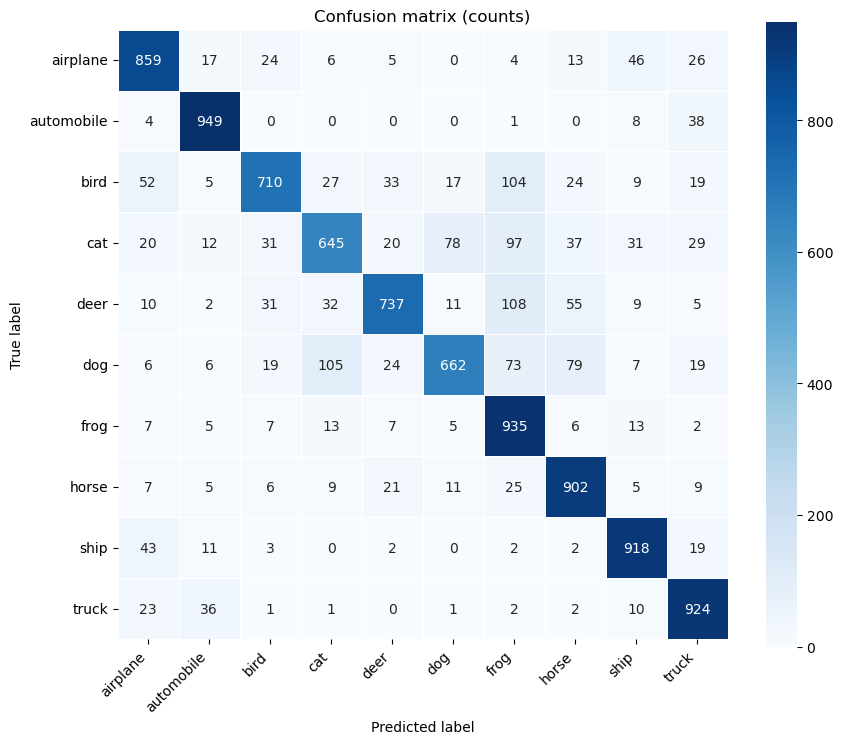

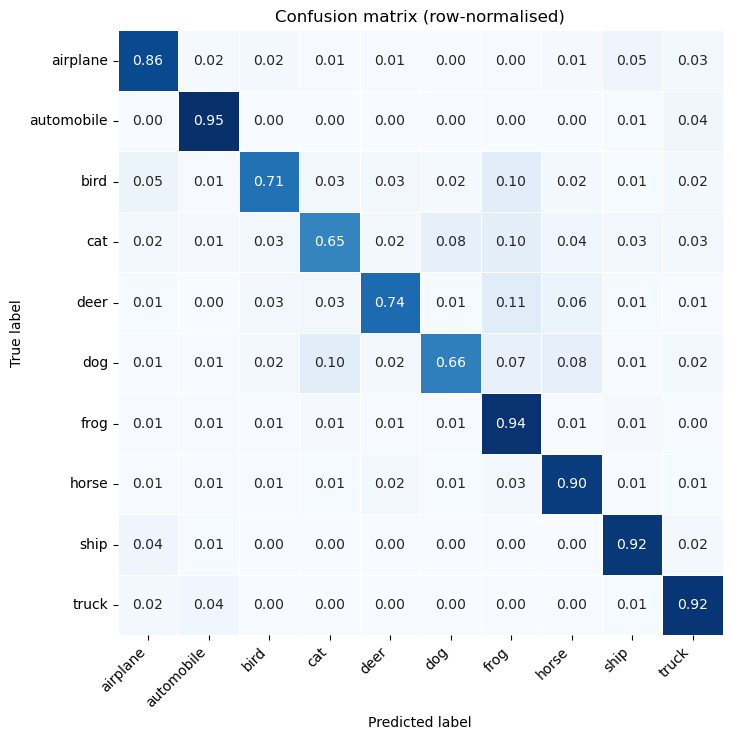

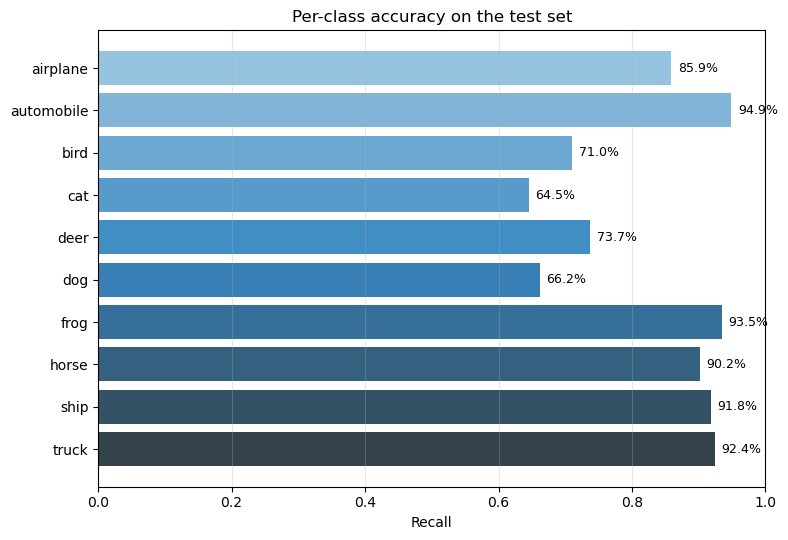

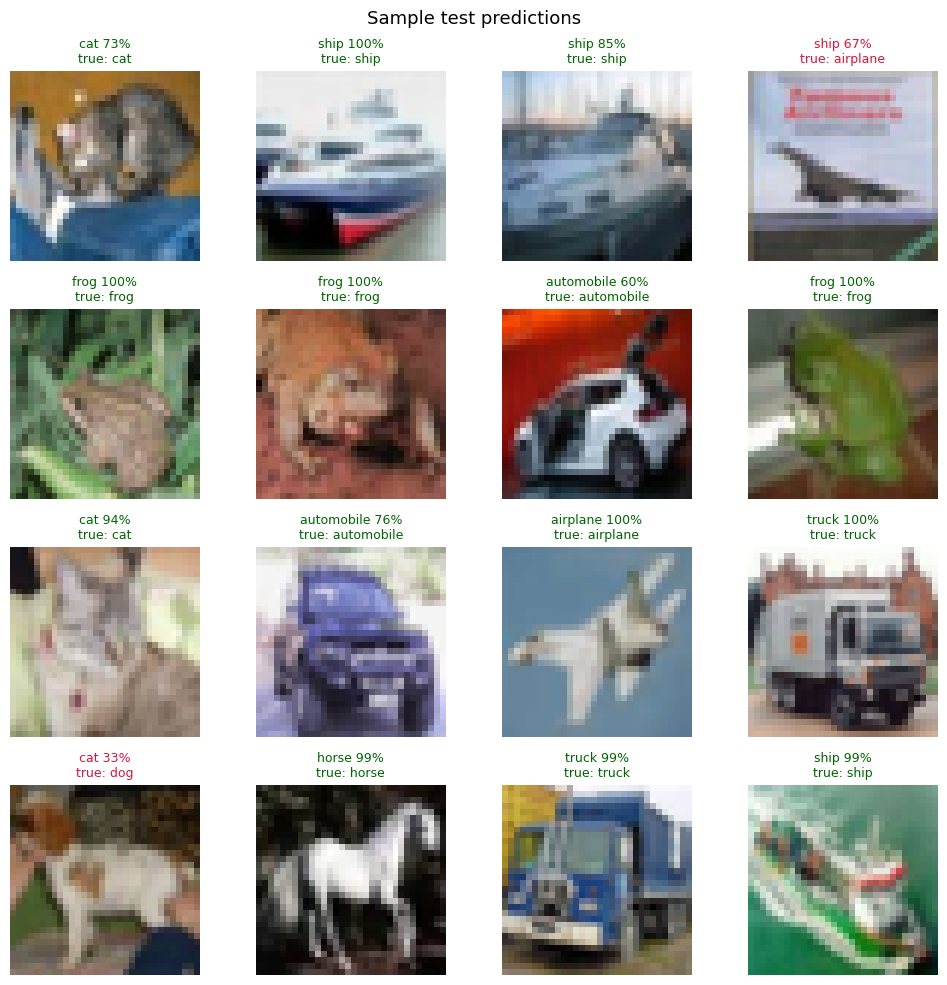


Test set evaluation
  samples        : 10000
  accuracy       : 0.8241
  top-3 accuracy : 0.9643
  macro F1       : 0.8212
  weighted F1    : 0.8212

Per-class recall
  airplane    recall 0.859  precision 0.833  f1 0.846  n=1000
  automobile  recall 0.949  precision 0.906  f1 0.927  n=1000
  bird        recall 0.710  precision 0.853  f1 0.775  n=1000
  cat         recall 0.645  precision 0.770  f1 0.702  n=1000
  deer        recall 0.737  precision 0.868  f1 0.797  n=1000
  dog         recall 0.662  precision 0.843  f1 0.742  n=1000
  frog        recall 0.935  precision 0.692  f1 0.795  n=1000
  horse       recall 0.902  precision 0.805  f1 0.851  n=1000
  ship        recall 0.918  precision 0.869  f1 0.893  n=1000
  truck       recall 0.924  precision 0.848  f1 0.884  n=1000

Confusion matrix (rows = true, columns = predicted)
          0   1   2   3   4   5   6   7   8   9
class 0: 859  17  24   6   5   0   4  13  46  26
class 1:   4 949   0   0   0   0   1   0   8  38
class 2:  52 

(0.8241, 0.9643)

In [28]:
evaluation = run_evaluation(CONFIG)
evaluation["summary"]["accuracy"], evaluation["summary"]["top_3_accuracy"]

### 10.2 Reload the saved predictions

The raw arrays are persisted to `.npz` so they can be analysed again later without re-running the model.

In [30]:
stored = np.load(REPORTS_DIR / f"{CONFIG.run_name}_predictions.npz")
print("arrays:", stored.files)
print("labels      :", stored["labels"].shape)
print("predictions :", stored["predictions"].shape)
print("probabilities:", stored["probabilities"].shape)

arrays: ['labels', 'predictions', 'probabilities']
labels      : (10000,)
predictions : (10000,)
probabilities: (10000, 10)


## 11. Single-image prediction

`run_prediction` classifies one image, either from a file on disk or from the CIFAR-10 test set by index. The trained checkpoint is reused.

In [31]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}


def load_image_batch(path: Path, image_size: int = IMAGE_SIZE) -> np.ndarray:
    """Read an image from disk as a (1, H, W, 3) float32 batch in [0, 1]."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    if path.suffix.lower() not in SUPPORTED_EXTENSIONS:
        raise ValueError(
            f"Unsupported image type '{path.suffix}'. "
            f"Expected one of: {', '.join(sorted(SUPPORTED_EXTENSIONS))}"
        )

    image = tf.keras.utils.load_img(path, target_size=(image_size, image_size))
    array = tf.keras.utils.img_to_array(image)
    return np.expand_dims(array / PIXEL_SCALE, axis=0).astype(np.float32)


def load_sample_batch(config: TrainConfig, index: int):
    """Return a (1, H, W, 3) batch and the true label for a test-set sample."""
    images, labels = load_test_arrays(config)
    if not 0 <= index < len(images):
        raise IndexError(f"index must be in [0, {len(images) - 1}], got {index}")

    batch = (images[index].astype(np.float32) / PIXEL_SCALE)[None, ...]
    return batch, int(labels[index])


def rank_predictions(
    probabilities: np.ndarray,
    top_k: int,
    class_names: tuple = CLASS_NAMES,
):
    """Return the top_k (class_name, probability) pairs, most likely first."""
    if probabilities.ndim == 2:
        probabilities = probabilities[0]

    top_k = max(1, min(top_k, len(class_names)))
    order = np.argsort(-probabilities)[:top_k]
    return [(class_names[int(i)], float(probabilities[int(i)])) for i in order]


def predict_batch(model, batch: np.ndarray, top_k: int = 3):
    """Run the model on a batch and return the ranked predictions."""
    probabilities = model.predict(batch, verbose=0)
    return rank_predictions(probabilities, top_k)


def run_prediction(
    config: TrainConfig,
    image_path=None,
    index: int = None,
    top_k: int = 3,
    model_path=None,
    show_image: bool = True,
) -> dict:
    """Classify one image (from disk or from the test set) and return the result."""
    ensure_directories()
    prepare_runtime()

    resolved_model_path = Path(model_path) if model_path else config.model_path
    if not resolved_model_path.exists():
        raise FileNotFoundError(
            f"No trained model at {resolved_model_path}. "
            "Run the training cell first."
        )

    if (image_path is None) == (index is None):
        raise ValueError("Provide exactly one of image_path or index")

    true_label = None
    if image_path is not None:
        batch = load_image_batch(image_path)
        source = str(image_path)
    else:
        batch, true_label = load_sample_batch(config, int(index))
        source = f"cifar10 test index {index}"

    model = load_trained_model(resolved_model_path)
    ranked = predict_batch(model, batch, top_k=top_k)
    best_name, best_probability = ranked[0]

    print()
    print(f"Source     : {source}")
    print(f"Prediction : {best_name} ({best_probability:.1%})")
    if true_label is not None:
        is_correct = CLASS_NAMES.index(best_name) == true_label
        verdict = "correct" if is_correct else "incorrect"
        print(f"True label : {CLASS_NAMES[true_label]}  [{verdict}]")

    print()
    print(f"Top {len(ranked)} predictions")
    for name, probability in ranked:
        print(f"  {name:<11} {probability:6.2%}")

    if show_image:
        plt.figure(figsize=(3, 3))
        plt.imshow(np.clip(batch[0], 0.0, 1.0))
        plt.title(f"predicted: {best_name}", fontsize=10)
        plt.axis("off")
        plt.show()

    return {
        "source": source,
        "prediction": best_name,
        "confidence": best_probability,
        "top_k": [{"class": name, "probability": probability} for name, probability in ranked],
        "true_label": None if true_label is None else CLASS_NAMES[true_label],
    }

### 11.1 Classify a test-set sample

Pick any index in `[0, 9999]`. Change `SAMPLE_INDEX` to try different images.


Source     : cifar10 test index 7
Prediction : frog (99.5%)
True label : frog  [correct]

Top 5 predictions
  frog        99.54%
  bird         0.38%
  deer         0.03%
  cat          0.01%
  airplane     0.01%


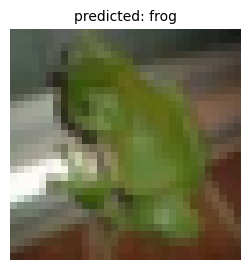

{'source': 'cifar10 test index 7',
 'prediction': 'frog',
 'confidence': 0.9954337477684021,
 'top_k': [{'class': 'frog', 'probability': 0.9954337477684021},
  {'class': 'bird', 'probability': 0.0037552500143647194},
  {'class': 'deer', 'probability': 0.0002952929644379765},
  {'class': 'cat', 'probability': 0.0001348967052763328},
  {'class': 'airplane', 'probability': 0.00012858609261456877}],
 'true_label': 'frog'}

In [32]:
SAMPLE_INDEX = 7
example = run_prediction(CONFIG, index=SAMPLE_INDEX, top_k=5)
example

### 11.2 Classify an image file

Point `IMAGE_PATH` at any JPG/PNG on disk. The image is resized to 32x32 automatically.


Source     : C:\Users\car info\Desktop/image_test.jpg
Prediction : truck (95.1%)

Top 5 predictions
  truck       95.10%
  automobile   2.86%
  ship         1.16%
  airplane     0.81%
  horse        0.04%


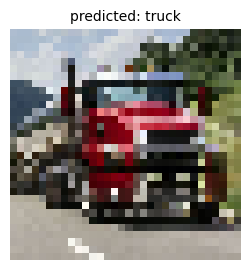

In [38]:
IMAGE_PATH = r"C:\Users\car info\Desktop/image_test.jpg"

if Path(IMAGE_PATH).exists():
    file_example = run_prediction(CONFIG, image_path=IMAGE_PATH, top_k=5)
else:
    print(f"No file at {IMAGE_PATH} - set IMAGE_PATH to a real image to run this cell.")

## 12. Notes and next steps

This notebook is self-contained: it needs no import from the `cifar10_cnn/` package. A few practical notes for running it in Anaconda:

* **CPU vs GPU.** The default `TrainConfig` is tuned for CPU: 60 epochs at batch size 64. On a GPU the same settings finish far quicker, and you can raise `batch_size` and `epochs`.
* **Smoke test first.** Set `CONFIG.quick_run = True` (Section 7, cell 7.1) to run 2 epochs on a 2,000-image subset and confirm every artifact is produced before a full run.
* **Where results land.** Everything is written under `artifacts/`: `models/<run_name>.keras` (best checkpoint), `reports/` (figures, JSON metrics, history, raw predictions) and `logs/<run_name>.csv` (per-epoch log).
* **Switching runs.** Change `CONFIG.run_name` to keep multiple experiments side by side; every artifact name is derived from it.
* **Reproducibility.** `CONFIG.seed` seeds Python, NumPy and TensorFlow. Exact bit-for-bit determinism on GPU additionally requires disabling cuDNN autotuning, which costs performance.
* **Augmentation ablation.** Set `CONFIG.use_augmentation = False` to reproduce a no-augmentation baseline.